In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
from ware_ops_pipes.utils.io_helpers import find_project_root
from ware_ops_algos.data_loaders import HesslerIrnichLoader
from experiments.evaluation.eval_commons import parse_solution_file, parse_solution_dir

In [10]:
def render_graph(G, ax=None, plot=True, out_name=False, draw_edge_labels=False,
                 with_labels=False, dpi=700, font_size=5, node_size=50,
                 show_legend=False) -> None:
    pos = nx.get_node_attributes(G, 'pos')
    node_types = nx.get_node_attributes(G, 'type')

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(dpi=dpi)

    type_styles = {
        'pick_node':         {'color': '#2A9D8F', 'size': 5,  'label': 'Storage location'},
        'change_aisle_node': {'color': '#264653', 'size': 10, 'label': 'Cross-aisle node'},
        'intersection': {'color': '#264653', 'size': 10, 'label': 'Cross-aisle node'},
        'start_node':        {'color': '#E76F51', 'size': 15, 'label': 'Start (depot)'},
        'end_node':          {'color': '#F4A261', 'size': 15, 'label': 'End (depot)'},
    }

    for ntype, style in type_styles.items():
        nodes = [n for n, t in node_types.items() if t == ntype]
        if nodes:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax,
                                   node_color=style['color'],
                                   node_size=style['size'],
                                   edgecolors='none')

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#404040', width=0.8)

    if draw_edge_labels:
        weight = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=weight,
                                     font_size=font_size, ax=ax)

    ax.set_facecolor('white')
    ax.axis('off')

    if show_legend:
        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=style['color'], markersize=6,
                       label=style['label'])
            for ntype, style in type_styles.items()
            if any(t == ntype for t in node_types.values())
        ]
        return legend_handles

    if standalone:
        fig.patch.set_facecolor('white')
        if out_name:
            plt.savefig(out_name, dpi=dpi, bbox_inches='tight', transparent=True)
        if plot:
            plt.show()

In [3]:
PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
results_dir = DATA_DIR / "results"

In [4]:
instance_set = "HennWaescherUniform"
instances_dir = DATA_DIR / "instances" / instance_set

il = HesslerIrnichLoader(instances_dir=instances_dir)
domain_henn = il.load("2l-20-45-0.txt")
graph_henn = domain_henn.layout.layout_network.graph

In [5]:
from ware_ops_algos.data_loaders import FoodmartLoader

instance_set = "FoodmartData"
instances_dir = DATA_DIR / "instances" / instance_set

il = FoodmartLoader(instances_dir=instances_dir)
domain_fm = il.load("instances_ord2000_fsd10_MAL.txt")
graph_fm = domain_fm.layout.layout_network.graph

In [14]:
from ware_ops_algos.data_loaders import IBRSPLoader

instance_set = "KrisSmallDataCorrected"
# instance_set = "KrisLargeData"
instances_dir = DATA_DIR / "instances" / instance_set

il = IBRSPLoader(instances_dir=instances_dir)
# domain_kris = il.load("instances_70_1.txt")
# domain_kris = il.load("instances_243_1.txt")
domain_kris = il.load("instances_220_1.txt")

graph_kris = domain_kris.layout.layout_network.graph
G_clean = graph_kris.copy()

pos = nx.get_node_attributes(G_clean, 'pos')
node_types = nx.get_node_attributes(G_clean, 'type')
# Find start and end depot positions
start_nodes = [n for n, t in node_types.items() if t == 'start_node']
end_nodes = [n for n, t in node_types.items() if t == 'end_node']
intersection_nodes = [n for n, t in node_types.items() if t == 'intersection']
G_clean.nodes[end_nodes[0]]['pos'] = (pos[end_nodes[0]][0] - 10.0, pos[end_nodes[0]][1])
            
            
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

In [15]:
intersection_nodes

[(0.0, 120.0),
 (0.0, 1351.0),
 (0.0, 2582.0),
 (144.0, 120.0),
 (144.0, 1351.0),
 (144.0, 2582.0),
 (192.0, 120.0),
 (192.0, 1351.0),
 (192.0, 2582.0),
 (240.0, 120.0),
 (240.0, 1351.0),
 (240.0, 2582.0),
 (288.0, 120.0),
 (288.0, 1351.0),
 (288.0, 2582.0),
 (336.0, 120.0),
 (336.0, 1351.0),
 (336.0, 2582.0),
 (384.0, 120.0),
 (384.0, 1351.0),
 (384.0, 2582.0),
 (432.0, 120.0),
 (432.0, 1351.0),
 (432.0, 2582.0),
 (480.0, 120.0),
 (480.0, 1351.0),
 (480.0, 2582.0),
 (528.0, 120.0),
 (528.0, 1351.0),
 (528.0, 2582.0),
 (576.0, 120.0),
 (576.0, 1351.0),
 (576.0, 2582.0),
 (768.0, 120.0),
 (768.0, 1351.0),
 (768.0, 2582.0)]

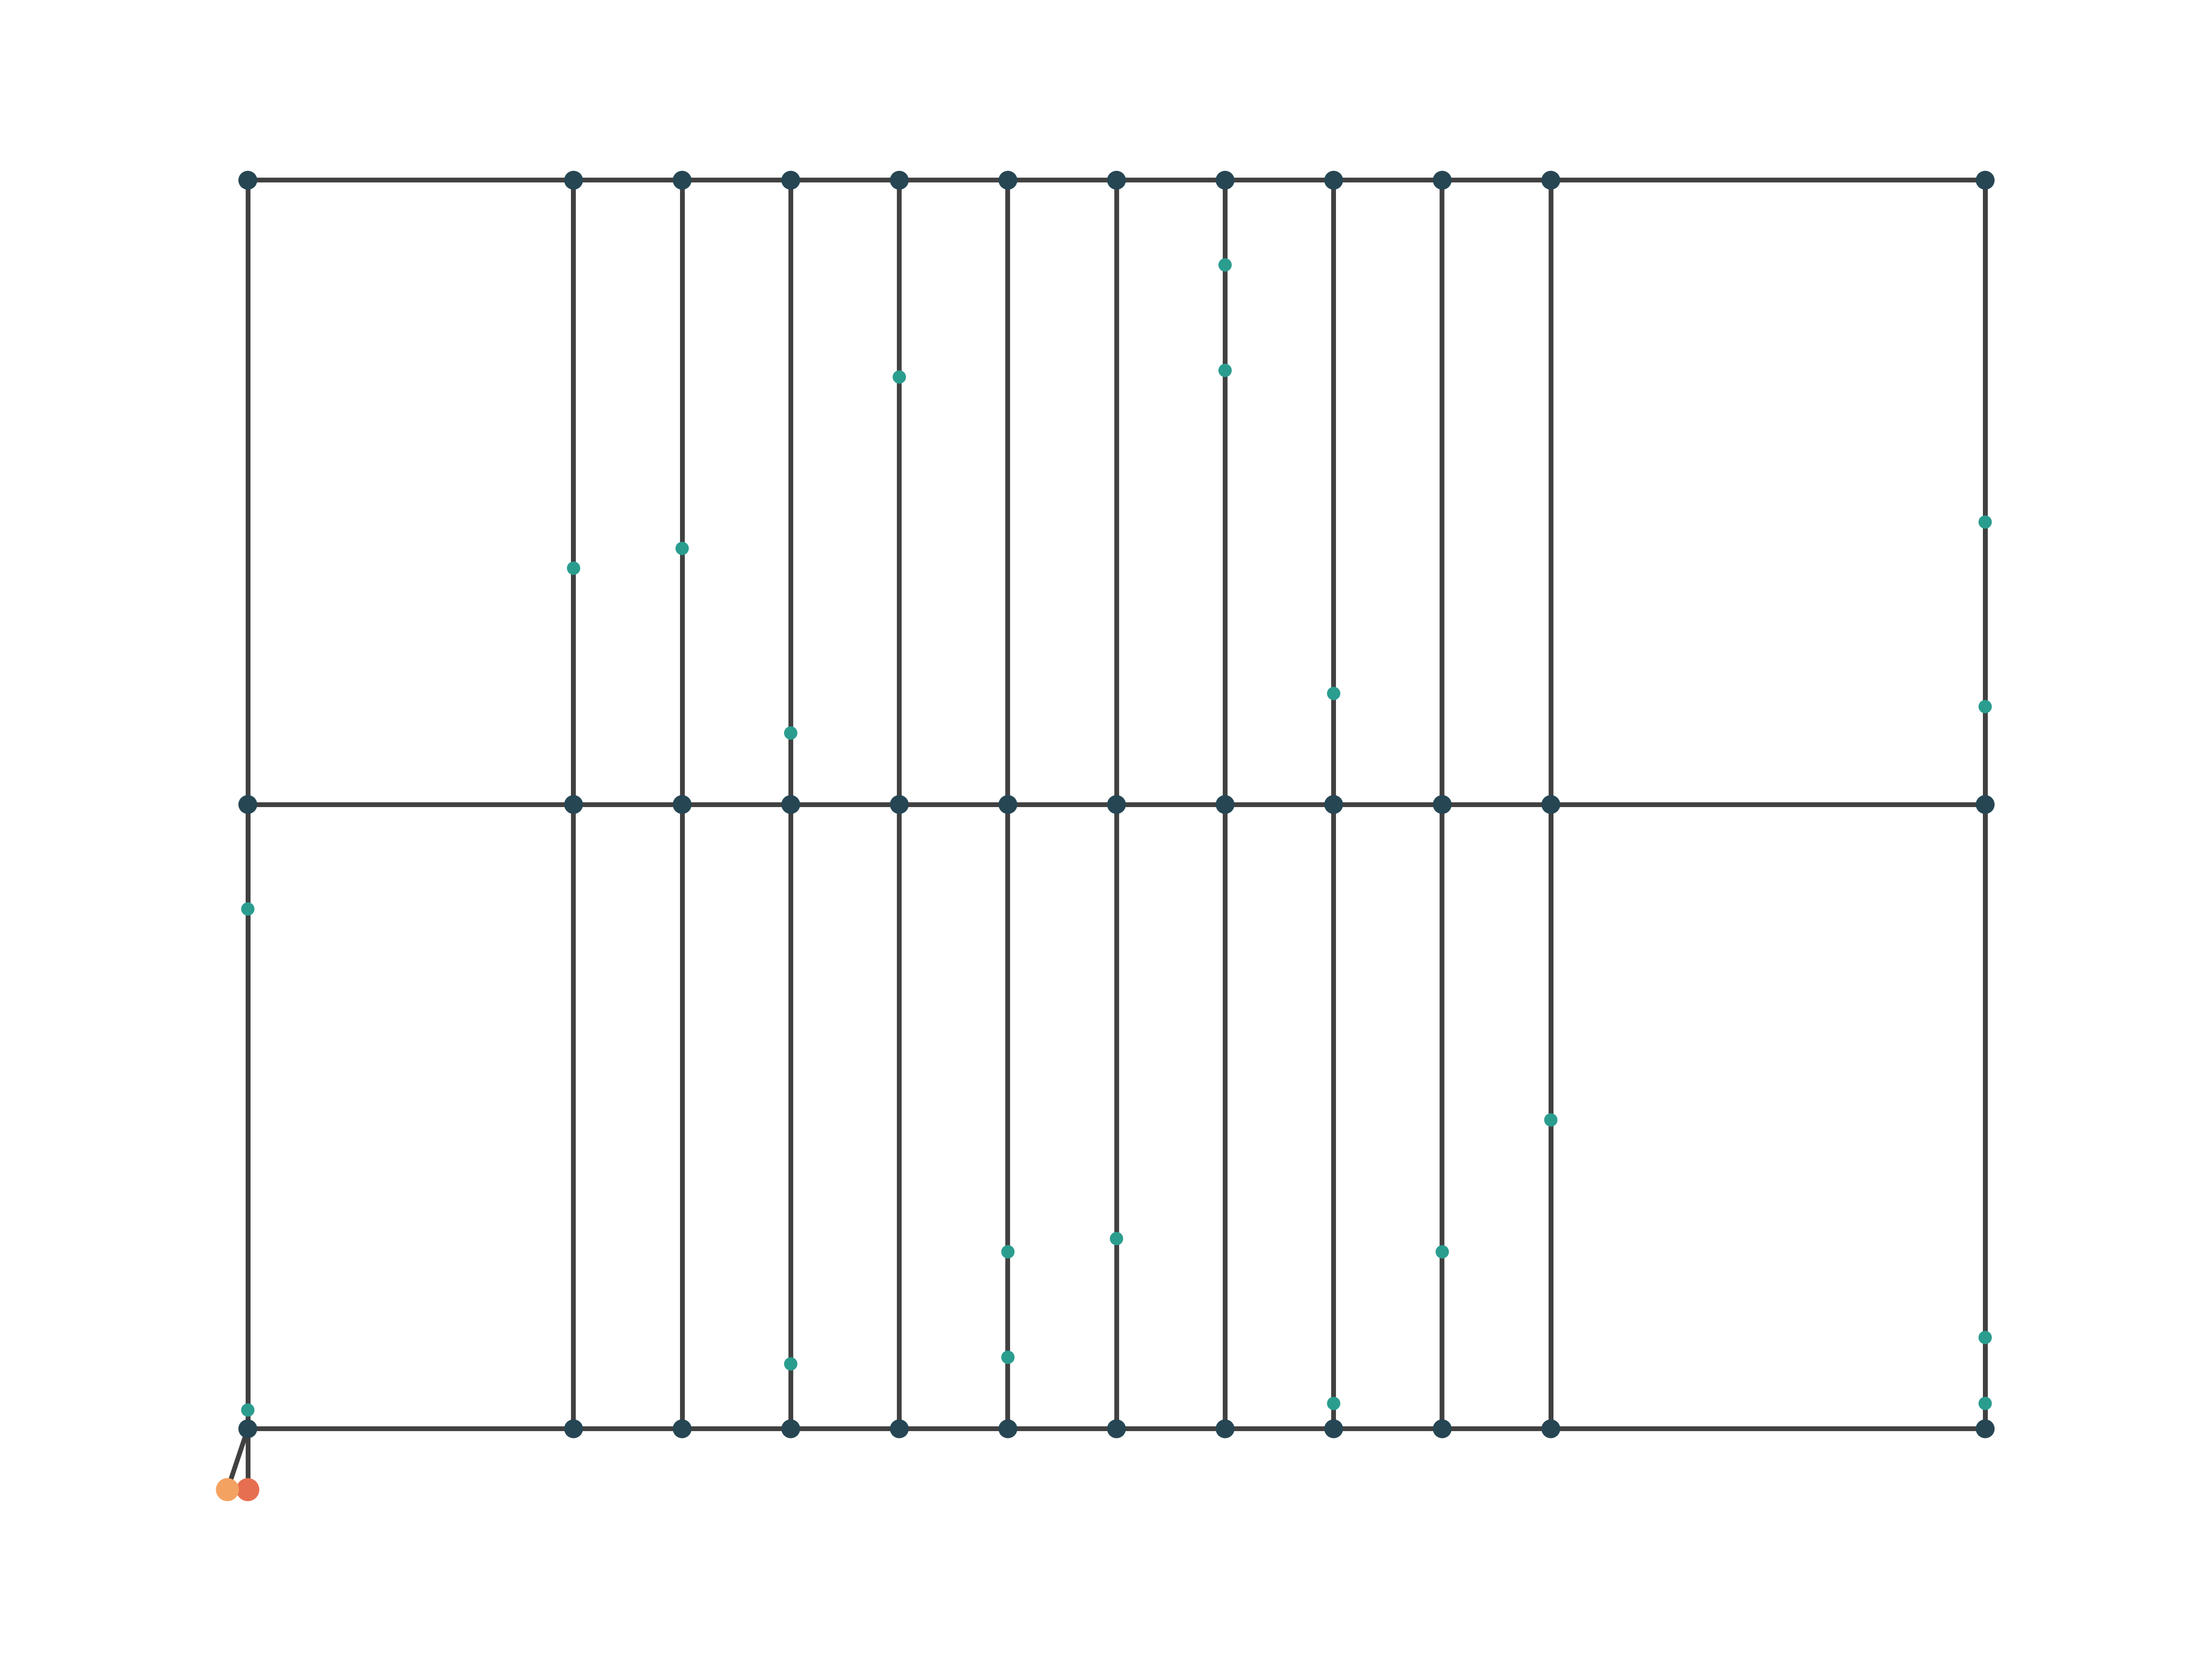

In [16]:
render_graph(G_clean)

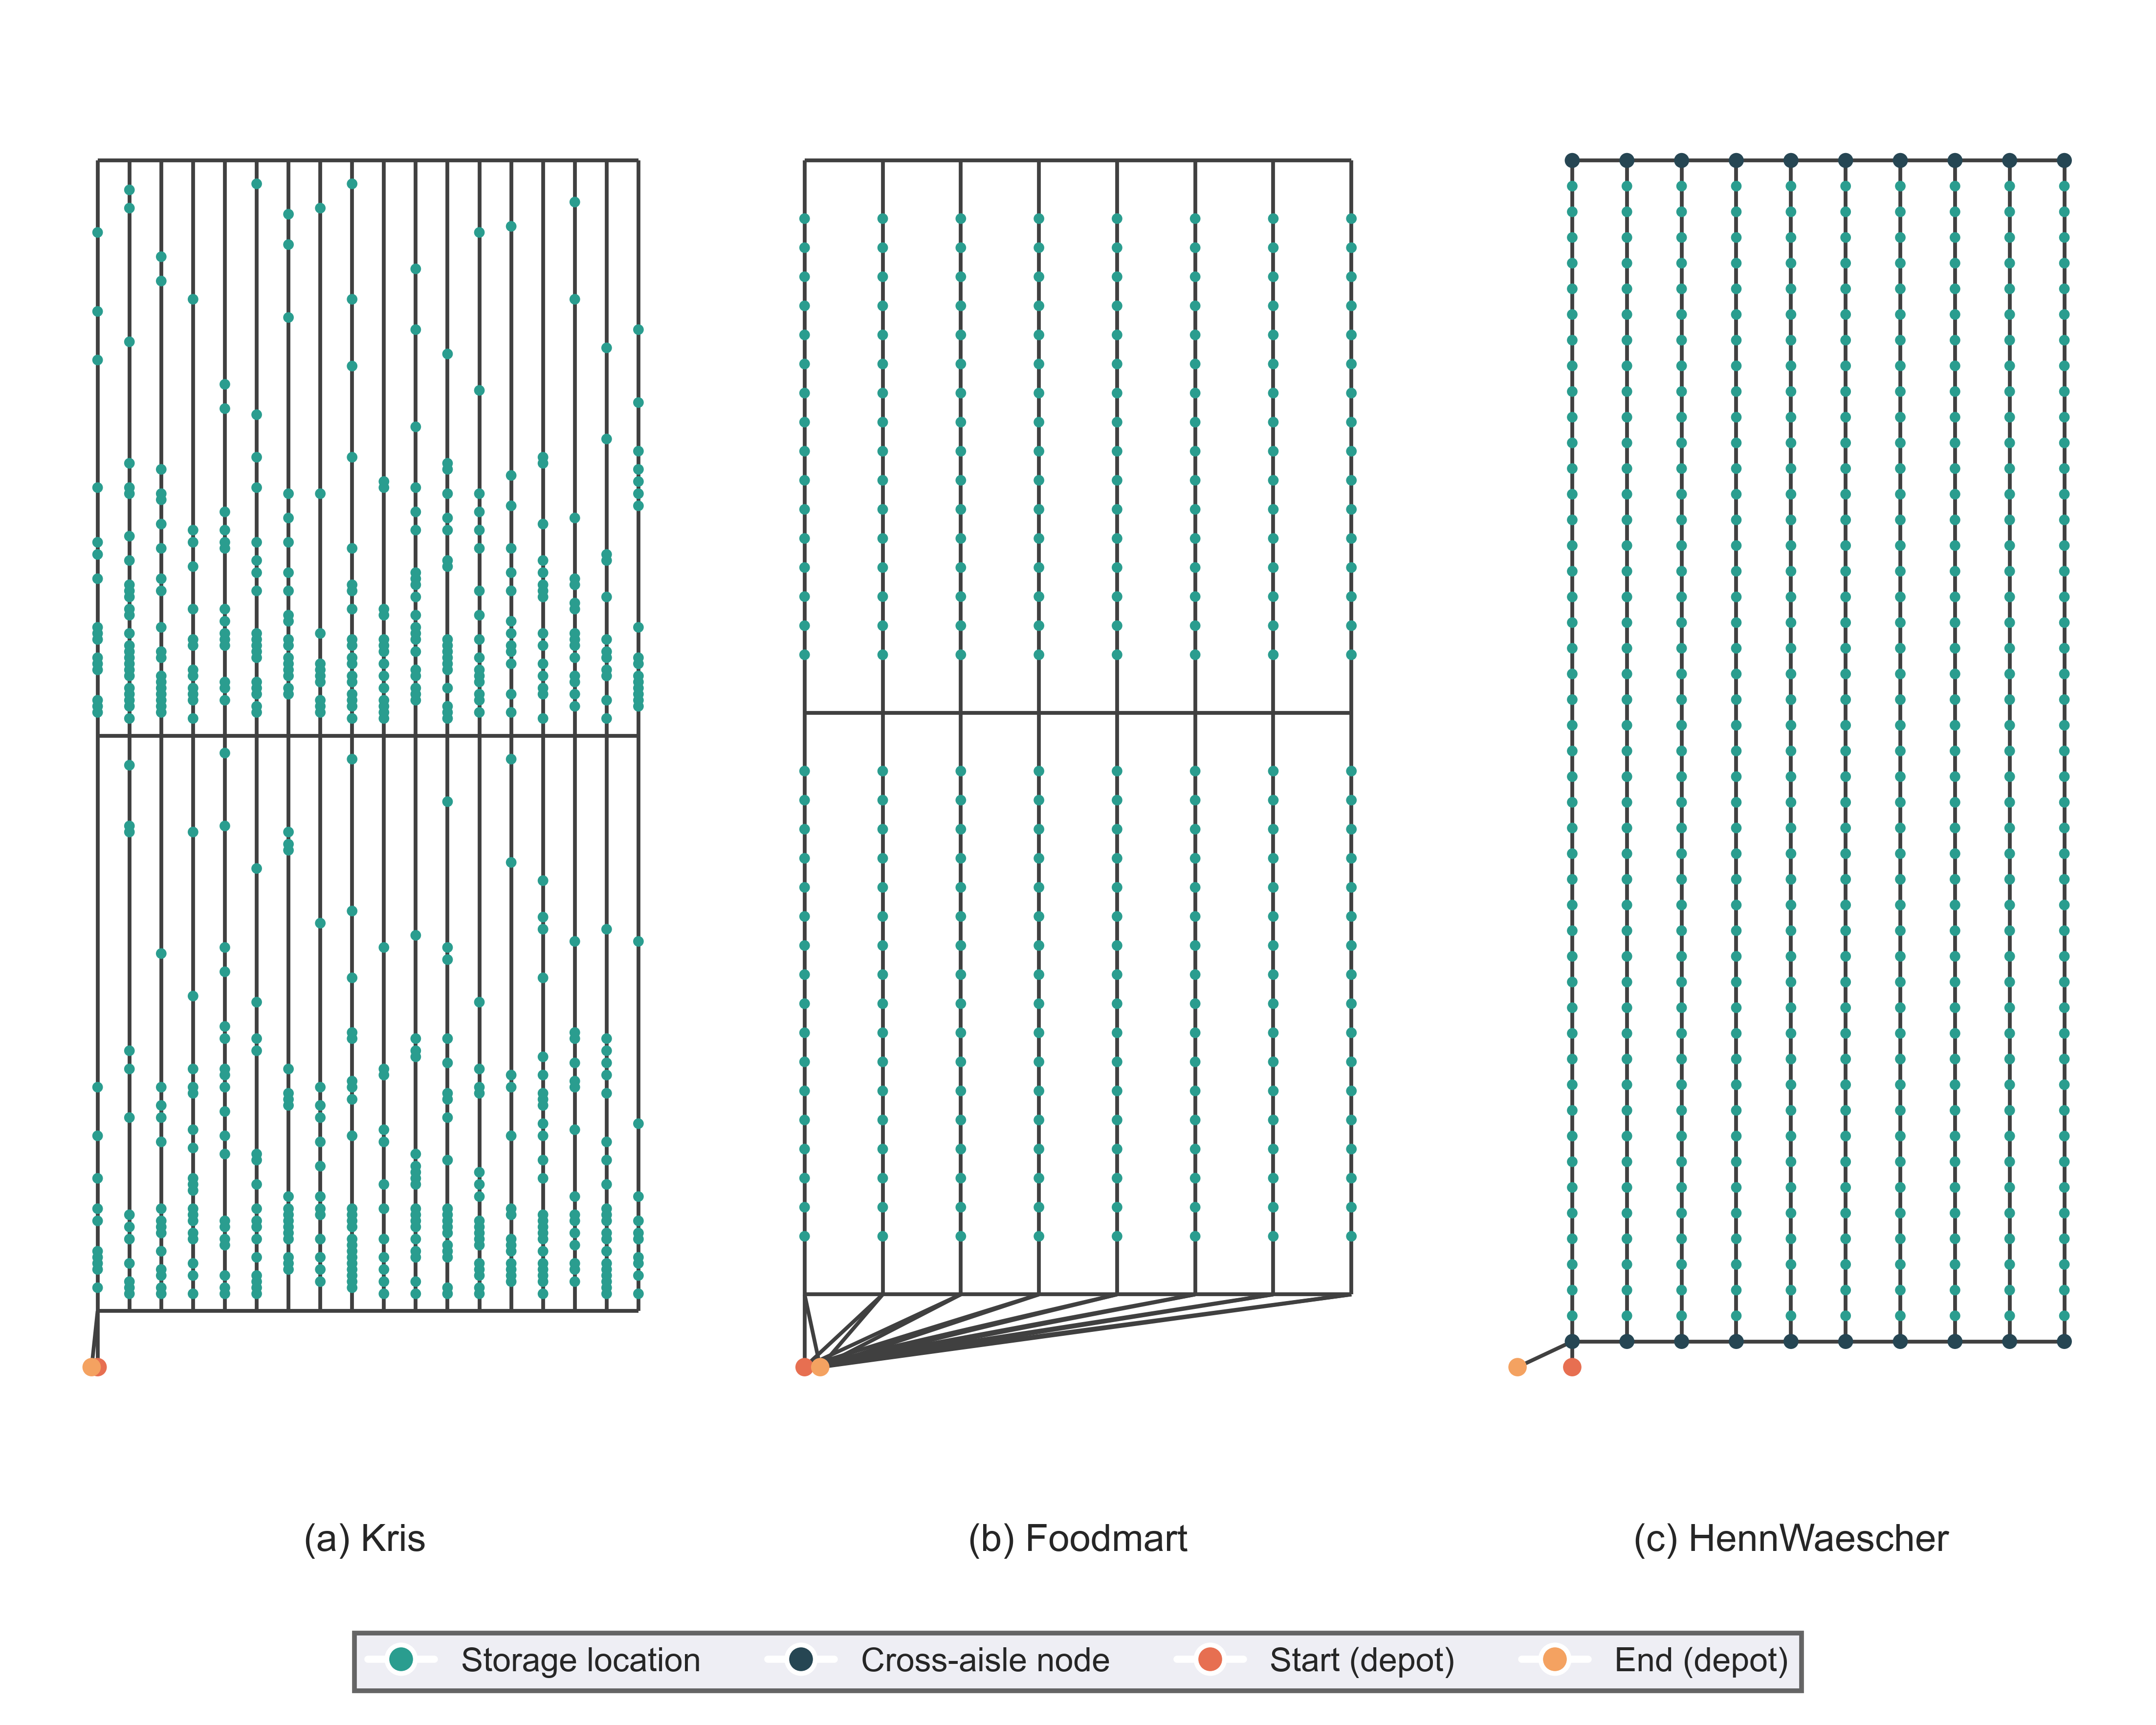

In [20]:
fig, axes = plt.subplots(1, 3, dpi=700)
fig.patch.set_facecolor('white')

render_graph(G_clean, ax=axes[0])
render_graph(graph_fm, ax=axes[1])
legend_handles = render_graph(graph_henn, ax=axes[2], show_legend=True)

# axes[0].set_title('(a) Kris', fontsize=8)
# axes[1].set_title('(b) Foodmart', fontsize=8)
# axes[2].set_title('(c) HennWaescher', fontsize=8)
for ax, label in zip(axes, ['(a) Kris', '(b) Foodmart', '(c) HennWaescher']):
    ax.text(0.5, -0.02, label, transform=ax.transAxes,
            fontsize=8, ha='center', va='top')

fig.legend(handles=legend_handles, loc='lower center',
           ncol=4, fontsize=7, frameon=True, fancybox=False,
           edgecolor='#404040', bbox_to_anchor=(0.5, -0.05))

fig.tight_layout()
fig.subplots_adjust(bottom=0.08)
plt.savefig('./plots/warehouse_layouts.pdf', dpi=700, bbox_inches='tight', transparent=True)
plt.show()

# Kris Summary

In [21]:
results_kris_small = parse_solution_dir(f"../../data/results/allSolutions/solutionssmall/")

In [22]:
results_kris_small["instance_name"] = (
    results_kris_small["instance_name"] + "_small"
)

In [23]:
results_kris_large = parse_solution_dir(f"../../data/results/allSolutions/solutionslarge/")

In [24]:
results_kris_large["instance_name"] = (
    results_kris_large["instance_name"] + "_large"
)

In [25]:
import pandas as pd

results_kris = pd.concat([results_kris_small, results_kris_large])

In [26]:
results_kris

,best_total_distance,best_makespan,best_tardiness,best_max_tardiness,best_on_time_rate,best_n_tardy,best_n_batches,n_orders,n_pickers,instance_name
0,16976,49152,0,0,100.0,0,3,18,2,instances_100_1_small
1,21726,99378,0,0,100.0,0,4,18,1,instances_101_1_small
2,17190,48168,0,0,100.0,0,3,18,2,instances_102_1_small
3,19680,56772,0,0,100.0,0,3,12,2,instances_103_1_small
4,17574,78222,0,0,100.0,0,3,12,1,instances_104_1_small
...,...,...,...,...,...,...,...,...,...,...
48,367584,123228,0,0,100.0,0,50,100,6,instances_90_1_large
49,246230,102096,0,0,100.0,0,25,101,4,instances_97_1_large
50,317214,111912,0,0,100.0,0,30,100,5,instances_98_1_large
51,312258,98932,0,0,100.0,0,30,100,5,instances_99_1_large
